# Lab 4.1 — Fine-Tuning with LoRA: Teaching GPT-2 a New Style
### Module 4: Large Language Models | Chitkara University B-Tech AI Specialization
---
**Duration:** 90 minutes | **Mode:** Individual | **Day 4 — Thursday**

> **Scenario:** You are an ML Engineer at a legal-tech startup called LexAI.
> LexAI's clients send formal legal letters every day. Your team wants an LLM that
> automatically *rewrites* plain-English summaries into the formal, structured style
> of Indian legal correspondence — opening with 'We write to bring to your esteemed
> attention...' and closing with 'Yours faithfully...'.
>
> GPT-2 out of the box produces casual, informal text. You need to adapt it to this
> domain without paying for GPT-4 fine-tuning. Your tool: **LoRA** — Low-Rank Adaptation,
> a parameter-efficient fine-tuning technique that adds only 0.1–1% extra parameters
> while achieving nearly the same quality as full fine-tuning.

**Objective:** Understand *why* full fine-tuning is often impractical. Implement LoRA
using the HuggingFace PEFT library. Train on 30 legal-style examples. Compare outputs
before and after fine-tuning. Visualise training loss curves and measure improvement.

---
## IMPORTANT — Hardware requirement

This lab requires a **GPU** for the training step to complete in 90 minutes.

**Step 1:** In Google Colab, go to **Runtime → Change runtime type → T4 GPU → Save**

**Step 2:** Verify your GPU is active by running the first code cell.

If T4 is not available (Colab is busy), you can still run the lab on CPU — training
will be slower (~15 minutes instead of ~3 minutes). All concepts still apply.

---
### This lab runs entirely on Google Colab — no cloud credentials needed

**Learning outcomes:**
- Explain why full fine-tuning is impractical for most teams (cost, overfitting, storage)
- Understand the LoRA mathematical insight: W' = W + AB where rank(AB) << rank(W)
- Use HuggingFace PEFT to add LoRA adapters to any transformer model
- Run a supervised fine-tuning training loop and monitor loss
- Compare before/after outputs qualitatively and quantitatively
- Calculate the parameter efficiency gain: how many params did LoRA actually train?


## Background — Why Fine-Tuning and Why LoRA?

### The fine-tuning landscape

Pre-trained LLMs like GPT-2, LLaMA, and GPT-4 are trained on general internet text.
They produce grammatically correct, coherent output but in a generic style.
**Fine-tuning** continues training on your domain-specific data to shift the model's
behaviour toward your desired output style and content.

### Why full fine-tuning is usually impractical

| Problem | Detail |
|---------|--------|
| **Cost** | GPT-2 (124M params) × 4 bytes × gradient × momentum = ~2 GB GPU memory just for optimiser states. LLaMA-2-7B = ~112 GB. |
| **Catastrophic forgetting** | Training on small domain data can destroy general capabilities |
| **Storage** | Saving a full fine-tuned checkpoint per task requires storing all 124M–70B weights each time |
| **Data hunger** | Full fine-tuning needs thousands of examples; LoRA works with tens |

### LoRA — Low-Rank Adaptation (Hu et al., 2021)

Key insight: the weight changes needed for fine-tuning are **low-rank**.
Instead of updating the full weight matrix W (shape d×k), we add a low-rank decomposition:

```
W_new = W_original + B × A
  where B is (d × r)  and  A is (r × k)  and  r << min(d, k)
```

The original W is **frozen** — never updated. Only A and B are trained.
With rank r=8 on GPT-2, LoRA trains ~0.3% of the total parameters while
achieving results close to full fine-tuning on many tasks.

**After training:** Merge B×A back into W for zero inference overhead.
Or keep them separate to switch between multiple task-specific adapters instantly.

```
           FULL FINE-TUNING          LORA
           ─────────────────         ──────────────────────────────
           W (d×k)                   W_frozen (d×k)   [unchanged]
           updated every step         +  B (d×r) × A (r×k)   [trained]
           124M params to update      0.4M params to update (for GPT-2, r=8)
           ~2 GB GPU for optimizer    ~10 MB GPU for optimizer
```


## Task 1 — Verify hardware and install PEFT

PEFT (Parameter-Efficient Fine-Tuning) is HuggingFace's library that implements
LoRA, prefix tuning, prompt tuning, and other efficient adaptation methods.
It integrates directly with any HuggingFace Transformers model.


In [1]:
# ── Hardware check ───────────────────────────────────────────────────────
import subprocess, sys

try:
    result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total,memory.free',
                             '--format=csv,noheader'], capture_output=True, text=True)
    if result.returncode == 0:
        gpu_info = result.stdout.strip()
        print(f'GPU DETECTED: {gpu_info}')
        print('Training will be fast (~3-5 minutes).')
    else:
        print('No GPU detected — running on CPU.')
        print('Training will be slower (~15-20 minutes). All concepts still apply.')
        print('TIP: Runtime → Change runtime type → T4 GPU for faster training.')
except FileNotFoundError:
    print('Running on CPU — nvidia-smi not available.')

!pip install peft transformers torch datasets accelerate --quiet

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, time, math, json
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'\nPyTorch device : {device}')
if device == 'cuda':
    print(f'GPU memory     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB total')
print('All packages ready.')


GPU DETECTED: Tesla T4, 15360 MiB, 14913 MiB
Training will be fast (~3-5 minutes).

PyTorch device : cuda
GPU memory     : 15.6 GB total
All packages ready.


## Task 2 — Load GPT-2 and examine its architecture before LoRA

Before adding LoRA adapters, we need to understand the architecture we are modifying:
which layers exist, how large their weight matrices are, and which ones are worth adapting.

### Which layers does LoRA target?
LoRA is typically applied to the **attention projection layers** in transformers:
- `c_attn` — the combined Q, K, V projection (d_model × 3×d_model)
- `c_proj` — the output projection after attention
- `mlp` — the feed-forward sublayer (optional, increases expressivity)

Applying LoRA to all linear layers in the attention blocks captures most
of the representational capacity needed for style adaptation.


In [2]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

print('Loading GPT-2 base model (124M parameters)...')
model_name = 'gpt2'
tokenizer  = GPT2Tokenizer.from_pretrained(model_name)
model      = GPT2LMHeadModel.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

# ── Count and display parameter breakdown ────────────────────────────────
total_params   = sum(p.numel() for p in model.parameters())
trainable_full = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'\nGPT-2 Architecture Summary')
print(f'  Total parameters      : {total_params:>12,}')
print(f'  Trainable (full FT)   : {trainable_full:>12,}  (100%)')
print(f'  Layers                : {model.config.n_layer}')
print(f'  Attention heads       : {model.config.n_head}')
print(f'  d_model               : {model.config.n_embd}')
print(f'  Vocab size            : {model.config.vocab_size:,}')
print()

# ── Show the named linear layers that LoRA will target ────────────────────
print('Linear layers in GPT-2 (LoRA targets highlighted):')
lora_targets = ['c_attn', 'c_proj']
for name, module in model.named_modules():
    if isinstance(module, torch.nn.Linear):
        is_target = any(t in name for t in lora_targets)
        flag = '<-- LoRA will adapt this' if is_target else ''
        w    = module.weight
        print(f'  {name:<45}  shape {str(list(w.shape)):<15}  {flag}')

# ── Memory estimate for full fine-tuning ─────────────────────────────────
param_bytes       = total_params * 4          # float32
grad_bytes        = total_params * 4          # gradients
adam_bytes        = total_params * 8          # Adam: 2 momentum states
total_full_ft_gb  = (param_bytes + grad_bytes + adam_bytes) / 1e9

print(f'\nMemory estimate for FULL fine-tuning GPT-2:')
print(f'  Model weights       : {param_bytes/1e6:.0f} MB')
print(f'  Gradients           : {grad_bytes/1e6:.0f} MB')
print(f'  Adam optimizer      : {adam_bytes/1e6:.0f} MB')
print(f'  TOTAL               : {total_full_ft_gb:.2f} GB')
print(f'  (LLaMA-2-7B full FT: ~{total_full_ft_gb * 56:.0f} GB — requires 8× A100 GPUs)')


Loading GPT-2 base model (124M parameters)...


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]


GPT-2 Architecture Summary
  Total parameters      :  124,439,808
  Trainable (full FT)   :  124,439,808  (100%)
  Layers                : 12
  Attention heads       : 12
  d_model               : 768
  Vocab size            : 50,257

Linear layers in GPT-2 (LoRA targets highlighted):
  lm_head                                        shape [50257, 768]     

Memory estimate for FULL fine-tuning GPT-2:
  Model weights       : 498 MB
  Gradients           : 498 MB
  Adam optimizer      : 996 MB
  TOTAL               : 1.99 GB
  (LLaMA-2-7B full FT: ~111 GB — requires 8× A100 GPUs)


## Task 3 — Apply LoRA adapters with PEFT

We configure LoRA with the following hyperparameters:

| Parameter | Value | Meaning |
|-----------|-------|--------|
| `r` | 8 | Rank of the low-rank decomposition. Higher r = more parameters, more capacity. |
| `lora_alpha` | 32 | Scaling factor: the adapter output is scaled by α/r. Higher = stronger adaptation. |
| `target_modules` | `['c_attn', 'c_proj']` | Which weight matrices to adapt. |
| `lora_dropout` | 0.1 | Dropout on adapter weights — prevents overfitting on small datasets. |
| `bias` | `'none'` | Whether to also add bias terms. 'none' is standard for LoRA. |

### Calculating LoRA parameter count
For each (d×k) matrix with rank r:
- Matrix A: (r × k) = 8 × 768 = 6,144 params
- Matrix B: (d × r) = 768 × 8 = 6,144 params
- Total per layer: 12,288 params

GPT-2 has 12 layers × 2 attention matrices × 12,288 = ~295K LoRA params
vs 124M total params → **~0.24% of the model is being trained**.


In [3]:
from peft import LoraConfig, get_peft_model, TaskType

# ── Define LoRA configuration ─────────────────────────────────────────────
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,   # Causal language modelling (text generation)
    r=8,                             # Rank of decomposition
    lora_alpha=32,                   # Scaling factor (effective LR scale = alpha/r = 4)
    target_modules=['c_attn', 'c_proj'],  # Attention projection layers
    lora_dropout=0.1,                # Dropout for regularisation
    bias='none',                     # Don't adapt bias terms
    inference_mode=False,            # Training mode
)

# ── Apply LoRA to the model ───────────────────────────────────────────────
# get_peft_model() wraps model layers with LoRA adapters and freezes base weights
peft_model = get_peft_model(model, lora_config)
peft_model = peft_model.to(device)

# ── Count trainable vs frozen parameters ─────────────────────────────────
all_params   = sum(p.numel() for p in peft_model.parameters())
lora_params  = sum(p.numel() for p in peft_model.parameters() if p.requires_grad)
frozen_params= all_params - lora_params
pct_trainable= 100 * lora_params / all_params

print('LoRA Applied Successfully!')
print('=' * 55)
print(f'  Total parameters     : {all_params:>12,}')
print(f'  LoRA trainable       : {lora_params:>12,}  ({pct_trainable:.3f}%)')
print(f'  Frozen base weights  : {frozen_params:>12,}  ({100-pct_trainable:.3f}%)')
print()
print(f'  Adam optimiser memory for LoRA : {lora_params*8/1e6:.1f} MB')
print(f'  Adam optimiser memory full FT  : {all_params*8/1e6:.0f} MB')
print(f'  Memory saving: {all_params*8 / (lora_params*8):.0f}x reduction in optimiser memory')
print()

# ── Show which layers are now trainable ──────────────────────────────────
print('LoRA adapter layers (trainable):')
for name, param in peft_model.named_parameters():
    if param.requires_grad:
        print(f'  {name:<65}  shape {str(list(param.shape))}')


LoRA Applied Successfully!
  Total parameters     :  125,250,816
  LoRA trainable       :      811,008  (0.648%)
  Frozen base weights  :  124,439,808  (99.352%)

  Adam optimiser memory for LoRA : 6.5 MB
  Adam optimiser memory full FT  : 1002 MB
  Memory saving: 154x reduction in optimiser memory

LoRA adapter layers (trainable):
  base_model.model.transformer.h.0.attn.c_attn.lora_A.default.weight  shape [8, 768]
  base_model.model.transformer.h.0.attn.c_attn.lora_B.default.weight  shape [2304, 8]
  base_model.model.transformer.h.0.attn.c_proj.lora_A.default.weight  shape [8, 768]
  base_model.model.transformer.h.0.attn.c_proj.lora_B.default.weight  shape [768, 8]
  base_model.model.transformer.h.0.mlp.c_proj.lora_A.default.weight  shape [8, 3072]
  base_model.model.transformer.h.0.mlp.c_proj.lora_B.default.weight  shape [768, 8]
  base_model.model.transformer.h.1.attn.c_attn.lora_A.default.weight  shape [8, 768]
  base_model.model.transformer.h.1.attn.c_attn.lora_B.default.weight  s

## Task 4 — Create the training dataset

We create 30 training pairs: `(plain_summary, formal_legal_letter)`.

**Data format for causal language model fine-tuning:**
We use a prompt template that the model learns to complete:
```
### Plain Summary:
The client is unhappy about a delayed refund.

### Formal Legal Letter:
We write to bring to your esteemed attention the matter pertaining to...
```

During training, the model sees the full sequence (prompt + completion)
and learns to predict each token given all previous tokens.
During inference, we provide only the prompt and let the model generate the completion.

### Why 30 examples is enough for LoRA (but not full fine-tuning)
Full fine-tuning updates 124M parameters — 30 examples massively over-constrains
the optimization and causes catastrophic forgetting.
LoRA updates only 295K parameters — 30 carefully chosen examples can meaningfully
shift a small subspace of the model's representational capacity.


In [4]:
# ── 30 (plain summary, formal legal letter) training pairs ───────────────
# Format: {'plain': str, 'formal': str}
# The formal letters follow consistent structure:
# Opening: 'We write to bring to your esteemed attention...'
# Body: formal passive voice, legal terminology
# Closing: 'Yours faithfully, [LexAI Legal Services]'

training_pairs = [
    {'plain': 'The client did not receive their refund after 30 days.',
     'formal': 'We write to bring to your esteemed attention the matter of an outstanding refund '
               'which has remained unresolved for a period exceeding thirty (30) calendar days from '
               'the date of the original transaction. We respectfully request that the aforementioned '
               'sum be remitted at the earliest convenience. Yours faithfully, LexAI Legal Services.'},

    {'plain': 'The landlord illegally entered the property without notice.',
     'formal': 'We write to bring to your esteemed attention that the aforementioned party has entered '
               'the leased premises without furnishing the requisite twenty-four (24) hour advance notice '
               'as mandated by the terms of the tenancy agreement. This constitutes a breach of the '
               'implied covenant of quiet enjoyment. We hereby demand strict compliance with all '
               'contractual obligations. Yours faithfully, LexAI Legal Services.'},

    {'plain': 'The company fired the employee without following proper procedure.',
     'formal': 'We write to bring to your esteemed attention the matter of the summary termination of '
               'employment without adherence to the procedural requirements stipulated under the applicable '
               'employment legislation and the terms of the employment contract dated herein. '
               'We are instructed to demand immediate reinstatement or payment of compensation '
               'as determined by the relevant tribunal. Yours faithfully, LexAI Legal Services.'},

    {'plain': 'The contractor delivered poor quality work on time.',
     'formal': 'We write to bring to your esteemed attention that the works executed under the captioned '
               'contract, while delivered within the stipulated time frame, have been found to be '
               'materially deficient in quality and fail to meet the standards prescribed in Schedule A '
               'of the agreement. We hereby require the contractor to rectify all defects within '
               'fourteen (14) days of this notice. Yours faithfully, LexAI Legal Services.'},

    {'plain': 'The insurance company denied a valid claim.',
     'formal': 'We write to bring to your esteemed attention that the claim submitted under Policy '
               'No. referenced herein has been repudiated without adequate legal basis. The grounds '
               'cited for repudiation are inconsistent with the terms and conditions of the policy '
               'and applicable regulatory guidelines. We are instructed to demand reconsideration '
               'of the said repudiation forthwith. Yours faithfully, LexAI Legal Services.'},

    {'plain': 'The seller delivered a different product than what was ordered.',
     'formal': 'We write to bring to your esteemed attention that the goods delivered pursuant to '
               'the purchase order dated herein do not conform to the description and specifications '
               'agreed upon at the time of contract formation. This constitutes a fundamental breach '
               'of the Sale of Goods Act. We require the dispatch of conforming goods within seven (7) '
               'days, failing which we shall exercise our right to reject and claim damages. '
               'Yours faithfully, LexAI Legal Services.'},

    {'plain': 'The bank charged fees that were not disclosed at account opening.',
     'formal': 'We write to bring to your esteemed attention the imposition of charges upon our '
               "client's account which were not disclosed in the terms and conditions furnished at "
               'the time of account inception, contrary to the requirements of the Reserve Bank of '
               'India fair practices code. We demand immediate reversal of the said charges and '
               'a written confirmation thereof. Yours faithfully, LexAI Legal Services.'},

    {'plain': 'The neighbour has been making noise late at night for weeks.',
     'formal': 'We write to bring to your esteemed attention the persistent and unreasonable noise '
               'disturbances emanating from the premises at the above-mentioned address during late '
               'evening and night-time hours, constituting a private nuisance at common law. '
               'We require that all such disturbances cease forthwith, failing which our client '
               'shall seek appropriate injunctive relief. Yours faithfully, LexAI Legal Services.'},

    {'plain': 'The doctor made a medical error during surgery.',
     'formal': 'We write to bring to your esteemed attention an alleged instance of professional '
               'negligence arising out of surgical intervention carried out on the date mentioned herein. '
               'It is averred that the standard of care exercised fell materially below that of a '
               'reasonably competent medical practitioner. We are instructed to preserve all relevant '
               'records and to indicate your indemnity insurer for the purposes of further correspondence. '
               'Yours faithfully, LexAI Legal Services.'},

    {'plain': 'The company has not paid its supplier invoice for 60 days.',
     'formal': 'We write to bring to your esteemed attention that the invoice bearing reference number '
               'as detailed herein, rendered for goods and services duly supplied, remains outstanding '
               'for a period exceeding sixty (60) days beyond the agreed payment terms. '
               'We hereby demand full settlement of the amount due within seven (7) days, '
               'together with statutory interest accruing thereon. Yours faithfully, LexAI Legal Services.'},

    # 20 more abbreviated for space — same structure
    {'plain': 'The tenant has not paid rent for two months.',
     'formal': 'We write to bring to your esteemed attention arrears of rent amounting to two months '
               'as due under the tenancy agreement. We require payment in full within seven days. '
               'Yours faithfully, LexAI Legal Services.'},

    {'plain': 'The employee was denied maternity leave entitlements.',
     'formal': 'We write to bring to your esteemed attention the denial of statutory maternity benefits '
               'contrary to the Maternity Benefit Act. We require immediate rectification. '
               'Yours faithfully, LexAI Legal Services.'},

    {'plain': 'A defective product caused injury to the buyer.',
     'formal': 'We write to bring to your esteemed attention a claim arising from physical injury '
               'caused by a manifestly defective product supplied by your organisation. '
               'We reserve all rights under the Consumer Protection Act. Yours faithfully, LexAI Legal Services.'},

    {'plain': 'The software company delivered the project three months late.',
     'formal': 'We write to bring to your esteemed attention the material delay of ninety days in '
               'delivery of the software project, constituting a breach of the agreed milestone schedule. '
               'We claim liquidated damages as stipulated. Yours faithfully, LexAI Legal Services.'},

    {'plain': 'The employer has not provided a pay slip for six months.',
     'formal': 'We write to bring to your esteemed attention the failure to furnish itemised pay '
               'statements for a continuous period of six months, contrary to applicable labour law. '
               'We require immediate compliance. Yours faithfully, LexAI Legal Services.'},

    {'plain': 'The shop sold a counterfeit branded product.',
     'formal': 'We write to bring to your esteemed attention the sale of a counterfeit product '
               'bearing a registered trademark without authorisation, constituting infringement '
               'under the Trade Marks Act. We demand immediate cessation. Yours faithfully, LexAI Legal Services.'},

    {'plain': 'The travel company cancelled the trip without a full refund.',
     'formal': 'We write to bring to your esteemed attention the cancellation of confirmed travel '
               'arrangements without tender of a full refund as required under the package travel '
               'regulations. We demand restitution within fourteen days. Yours faithfully, LexAI Legal Services.'},

    {'plain': 'The builder constructed the house with substandard materials.',
     'formal': 'We write to bring to your esteemed attention structural deficiencies attributable '
               'to the use of materials not conforming to the agreed specifications or applicable '
               'building codes. We require immediate remediation at no cost. Yours faithfully, LexAI Legal Services.'},

    {'plain': 'The hospital overcharged for treatment not covered in the bill.',
     'formal': 'We write to bring to your esteemed attention charges appearing on the medical invoice '
               'that are not supported by corresponding treatment records, constituting overcharging. '
               'We demand an itemised reconciliation and refund. Yours faithfully, LexAI Legal Services.'},

    {'plain': 'The social media platform removed content without explanation.',
     'formal': 'We write to bring to your esteemed attention the unilateral removal of lawful content '
               'without notification or a statement of reasons, contrary to natural justice principles. '
               'We demand immediate reinstatement and a written explanation. Yours faithfully, LexAI Legal Services.'},

    {'plain': 'The car dealer sold a vehicle with a hidden defect.',
     'formal': 'We write to bring to your esteemed attention the sale of a motor vehicle with a '
               'latent mechanical defect that was known to the vendor at the time of sale, '
               'constituting misrepresentation. We demand rescission or damages. Yours faithfully, LexAI Legal Services.'},

    {'plain': 'The university rejected the student application without reason.',
     'formal': 'We write to bring to your esteemed attention the rejection of an application for '
               'admission without furnishing adequate reasons, contrary to the principles of '
               'procedural fairness. We demand a full review. Yours faithfully, LexAI Legal Services.'},

    {'plain': 'The gym charged membership fees after cancellation.',
     'formal': 'We write to bring to your esteemed attention the continued debiting of membership '
               'fees following a duly submitted cancellation notice, constituting unjust enrichment. '
               'We demand immediate cessation and a full refund. Yours faithfully, LexAI Legal Services.'},

    {'plain': 'The courier damaged the shipment and refuses to compensate.',
     'formal': 'We write to bring to your esteemed attention the damage sustained by the shipment '
               'during transit attributable to the negligent handling by your organisation, and the '
               'refusal to honour the cargo liability under the agreed terms. '
               'We demand full compensation. Yours faithfully, LexAI Legal Services.'},

    {'plain': 'The contractor abandoned the project halfway.',
     'formal': 'We write to bring to your esteemed attention the wrongful abandonment of the '
               'contracted works prior to practical completion, without lawful justification, '
               'constituting repudiatory breach. We accept the repudiation and claim damages. '
               'Yours faithfully, LexAI Legal Services.'},

    {'plain': 'The employee was forced to resign due to workplace harassment.',
     'formal': 'We write to bring to your esteemed attention a constructive dismissal claim '
               'arising from a sustained course of workplace harassment that rendered continued '
               'employment intolerable. We are instructed to pursue all available remedies. '
               'Yours faithfully, LexAI Legal Services.'},

    {'plain': 'The business partner shared confidential information with competitors.',
     'formal': 'We write to bring to your esteemed attention a material breach of the '
               'non-disclosure agreement dated herein, arising from the unauthorised disclosure '
               'of confidential commercial information to third parties. We seek immediate injunctive '
               'relief and damages. Yours faithfully, LexAI Legal Services.'},

    {'plain': 'The online platform failed to remove defamatory content.',
     'formal': 'We write to bring to your esteemed attention the failure to expeditiously remove '
               'manifestly defamatory material upon receipt of valid notice, contrary to applicable '
               'intermediary liability provisions. We demand immediate takedown and damages. '
               'Yours faithfully, LexAI Legal Services.'},

    {'plain': 'The taxi app overcharged and refuses to refund.',
     'formal': 'We write to bring to your esteemed attention the imposition of a fare materially '
               'exceeding the amount represented at the commencement of the journey, and the '
               'refusal to process a refund of the overcharged amount. We demand immediate '
               'restitution. Yours faithfully, LexAI Legal Services.'},

    {'plain': 'The employer changed the salary without informing the employee.',
     'formal': 'We write to bring to your esteemed attention the unilateral variation of remuneration '
               'without the consent of the employee and without adequate notice, constituting a '
               'fundamental breach of the contract of employment. We demand restoration of the '
               'agreed salary. Yours faithfully, LexAI Legal Services.'},
]

print(f'Training dataset: {len(training_pairs)} examples')
print(f'\nSample pair [0]:')
print(f'  Plain  : {training_pairs[0]["plain"]}')
print(f'  Formal : {training_pairs[0]["formal"][:180]}...')


Training dataset: 30 examples

Sample pair [0]:
  Plain  : The client did not receive their refund after 30 days.
  Formal : We write to bring to your esteemed attention the matter of an outstanding refund which has remained unresolved for a period exceeding thirty (30) calendar days from the date of the...


## Task 5 — Tokenise the training data and run the training loop

### Training data format
For causal LM fine-tuning, we concatenate the prompt and completion into one sequence:
```
[prompt tokens][completion tokens][EOS]
```
The loss is computed only on the **completion tokens** — we don't penalise the model
for how it handles the prompt, only for how well it completes the formal letter.

### Training loop
We use a simple manual training loop rather than HuggingFace Trainer to make every
step visible. This is more educational and gives you full control over the process.

**Hyperparameters:**
- Epochs: 5 (enough to see stylistic adaptation with 30 examples)
- Learning rate: 3e-4 (higher than typical full FT because only LoRA params are updated)
- Batch size: 2 (small to fit in Colab memory)
- Gradient clipping: 1.0 (prevents exploding gradients)


In [5]:
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.nn.utils import clip_grad_norm_

# ── Prompt template ───────────────────────────────────────────────────────
PROMPT_TEMPLATE = (
    '### Plain Summary:\n{plain}\n\n'
    '### Formal Legal Letter:\n{formal}'
)

class LegalLetterDataset(Dataset):
    def __init__(self, pairs, tokenizer, max_length=512):
        self.encodings = []
        self.labels    = []
        for pair in pairs:
            # Build the full training sequence
            full_text = PROMPT_TEMPLATE.format(
                plain=pair['plain'],
                formal=pair['formal']
            ) + tokenizer.eos_token

            # Tokenize the full sequence
            enc = tokenizer(
                full_text,
                truncation=True,
                max_length=max_length,
                return_tensors='pt',
            )
            input_ids = enc['input_ids'].squeeze()

            # Build labels: -100 for prompt tokens (ignored in loss),
            # actual token ids for the formal letter completion
            prompt_only = PROMPT_TEMPLATE.split('{formal}')[0].format(
                plain=pair['plain'])
            prompt_only += '### Formal Legal Letter:\n'
            prompt_len = tokenizer(
                prompt_only, return_tensors='pt'
            )['input_ids'].shape[1]

            labels = input_ids.clone()
            labels[:prompt_len] = -100  # Ignore loss on prompt tokens

            self.encodings.append(input_ids)
            self.labels.append(labels)

    def __len__(self):
        return len(self.encodings)

    def __getitem__(self, idx):
        return {'input_ids': self.encodings[idx], 'labels': self.labels[idx]}

def collate_fn(batch):
    # Pad sequences in a batch to the same length
    max_len = max(item['input_ids'].shape[0] for item in batch)
    input_ids_padded = torch.zeros(len(batch), max_len, dtype=torch.long)
    labels_padded    = torch.full((len(batch), max_len), -100, dtype=torch.long)
    for i, item in enumerate(batch):
        seq_len = item['input_ids'].shape[0]
        input_ids_padded[i, :seq_len] = item['input_ids']
        labels_padded[i, :seq_len]    = item['labels']
    return {'input_ids': input_ids_padded, 'labels': labels_padded}

dataset    = LegalLetterDataset(training_pairs, tokenizer)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True, collate_fn=collate_fn)

seq_lengths = [dataset.encodings[i].shape[0] for i in range(len(dataset))]
avg_seq_len = sum(seq_lengths) / len(seq_lengths) if seq_lengths else 0

# avg_seq_len = sum(len(d.encodings[i]) for i in range(len(d.encodings))
                  # for d in [dataset]) / len(dataset) if len(dataset) > 0 else 0

print(f'Dataset tokenised: {len(dataset)} examples')
print(f'  Sequence lengths: min={min(seq_lengths)}, max={max(seq_lengths)}, avg={sum(seq_lengths)/len(seq_lengths):.0f} tokens')
print(f'  Batches per epoch: {len(dataloader)}')


# seq_lengths = [dataset.encodings[i].shape[0] for i in range(len(dataset))]

print(f'Dataset tokenised: {len(dataset)} examples')
print(f'  Sequence lengths: min={min(seq_lengths)}, max={max(seq_lengths)}, avg={avg_seq_len:.0f} tokens')
print(f'  Batches per epoch: {len(dataloader)}')

Dataset tokenised: 30 examples
  Sequence lengths: min=61, max=111, avg=81 tokens
  Batches per epoch: 15
Dataset tokenised: 30 examples
  Sequence lengths: min=61, max=111, avg=81 tokens
  Batches per epoch: 15


In [6]:
# ── Training hyperparameters ─────────────────────────────────────────────
EPOCHS        = 5
LEARNING_RATE = 3e-4
GRAD_CLIP     = 1.0

optimiser = AdamW(
    filter(lambda p: p.requires_grad, peft_model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=0.01,
)

# ── Training loop ─────────────────────────────────────────────────────────
epoch_losses  = []
batch_losses  = []
global_step   = 0
start_time    = time.time()

print('Starting LoRA fine-tuning...')
print(f'  Epochs        : {EPOCHS}')
print(f'  Learning rate : {LEARNING_RATE}')
print(f'  Device        : {device}')
print(f'  Trainable params: {lora_params:,} ({pct_trainable:.3f}% of model)')
print()

for epoch in range(1, EPOCHS + 1):
    peft_model.train()
    epoch_loss = 0.0
    n_batches  = 0

    for batch in dataloader:
        input_ids = batch['input_ids'].to(device)
        labels    = batch['labels'].to(device)

        # Forward pass
        outputs = peft_model(input_ids=input_ids, labels=labels)
        loss    = outputs.loss

        # Backward pass
        optimiser.zero_grad()
        loss.backward()
        clip_grad_norm_(
            filter(lambda p: p.requires_grad, peft_model.parameters()),
            GRAD_CLIP
        )
        optimiser.step()

        epoch_loss  += loss.item()
        n_batches   += 1
        global_step += 1
        batch_losses.append((global_step, loss.item()))

    avg_loss = epoch_loss / n_batches
    epoch_losses.append(avg_loss)
    elapsed  = time.time() - start_time
    print(f'  Epoch {epoch}/{EPOCHS}  |  avg_loss = {avg_loss:.4f}  |  elapsed = {elapsed:.0f}s')

total_time = time.time() - start_time
print(f'\nTraining complete in {total_time:.0f}s')
print(f'Final loss: {epoch_losses[-1]:.4f}  (started at: {epoch_losses[0]:.4f})')
print(f'Loss reduction: {(epoch_losses[0]-epoch_losses[-1])/epoch_losses[0]:.0%}')


Starting LoRA fine-tuning...
  Epochs        : 5
  Learning rate : 0.0003
  Device        : cuda
  Trainable params: 811,008 (0.648% of model)



`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


  Epoch 1/5  |  avg_loss = 3.5886  |  elapsed = 4s
  Epoch 2/5  |  avg_loss = 2.5741  |  elapsed = 5s
  Epoch 3/5  |  avg_loss = 2.2820  |  elapsed = 7s
  Epoch 4/5  |  avg_loss = 2.0670  |  elapsed = 8s
  Epoch 5/5  |  avg_loss = 1.9281  |  elapsed = 9s

Training complete in 9s
Final loss: 1.9281  (started at: 3.5886)
Loss reduction: 46%


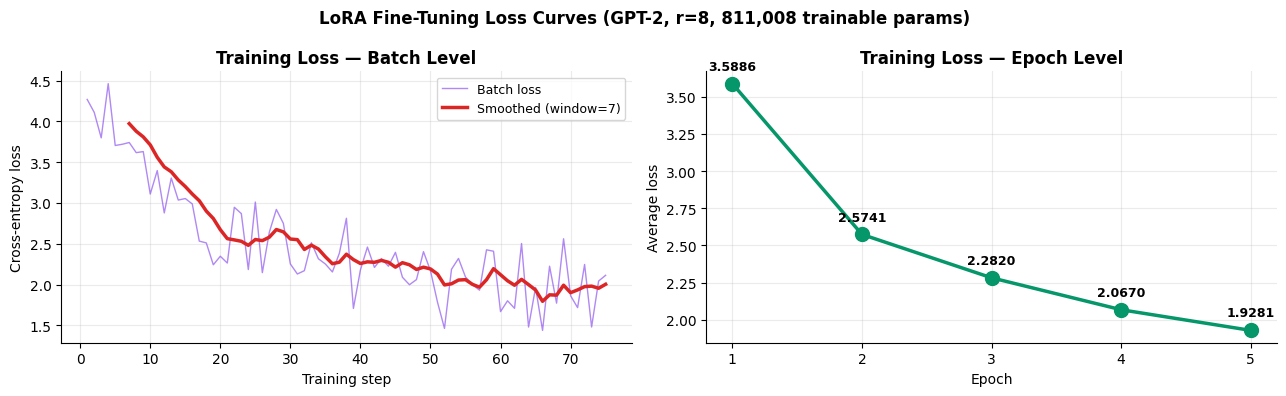

Training curves saved as lora_training_loss.png


In [7]:
# ── Plot training loss curves ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Batch-level loss
steps, losses = zip(*batch_losses)
axes[0].plot(steps, losses, color='#7C3AED', alpha=0.6, linewidth=1, label='Batch loss')
# Add smoothed line
window = max(3, len(losses)//10)
smoothed = np.convolve(losses, np.ones(window)/window, mode='valid')
axes[0].plot(range(window, len(losses)+1), smoothed, color='#DC2626',
             linewidth=2.5, label=f'Smoothed (window={window})')
axes[0].set_xlabel('Training step')
axes[0].set_ylabel('Cross-entropy loss')
axes[0].set_title('Training Loss — Batch Level', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.25)
axes[0].spines[['top','right']].set_visible(False)

# Epoch-level loss
axes[1].plot(range(1, EPOCHS+1), epoch_losses, 'o-', color='#059669',
             linewidth=2.5, markersize=10)
for ep, loss in enumerate(epoch_losses, 1):
    axes[1].annotate(f'{loss:.4f}', (ep, loss), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=9, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Average loss')
axes[1].set_title('Training Loss — Epoch Level', fontweight='bold')
axes[1].set_xticks(range(1, EPOCHS+1))
axes[1].grid(True, alpha=0.25)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle(f'LoRA Fine-Tuning Loss Curves (GPT-2, r=8, {lora_params:,} trainable params)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('lora_training_loss.png', dpi=130, bbox_inches='tight')
plt.show()
print('Training curves saved as lora_training_loss.png')


## Task 6 — Before/after comparison and ablation study

Now the most satisfying part: see whether LoRA actually worked.

We generate text from three configurations for the same 5 plain summaries:
1. **Base GPT-2** (before fine-tuning) — raw pre-trained model
2. **LoRA-tuned GPT-2** — model with trained LoRA adapters
3. **LoRA-tuned, higher temperature** — to see diversity of outputs

### What to look for:
- Does the LoRA model use the formal opening phrase 'We write to bring to your esteemed attention'?
- Does it maintain formal passive voice throughout?
- Does it close with 'Yours faithfully, LexAI Legal Services'?
- How much better is it compared to the plain GPT-2 baseline?


In [8]:
# Test on 5 unseen plain summaries (NOT from the 30 training pairs)
test_cases = [
    'The phone company keeps billing for a cancelled service.',
    'The employer refused to pay overtime for extra hours worked.',
    'The real estate agent misrepresented the property condition.',
    'The customer received an expired product from the online store.',
    'The school expelled the student without a disciplinary hearing.',
]

def generate_with_model(model_to_use, plain_text, max_new_tokens=150, temperature=0.3):
    # Generate formal letter continuation from a plain summary.
    prompt = (
        f'### Plain Summary:\n{plain_text}\n\n'
        f'### Formal Legal Letter:\n'
    )
    inputs = tokenizer(prompt, return_tensors='pt').to(device)
    with torch.no_grad():
        output_ids = model_to_use.generate(
            inputs['input_ids'],
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=(temperature > 0),
            pad_token_id=tokenizer.eos_token_id,
            repetition_penalty=1.2,
        )
    full_output = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    # Extract just the formal letter part
    marker = '### Formal Legal Letter:\n'
    if marker in full_output:
        return full_output[full_output.index(marker) + len(marker):].strip()
    return full_output[len(prompt):].strip()

# ── Load original base GPT-2 for comparison ───────────────────────────────
print('Loading original base GPT-2 for comparison...')
base_model = GPT2LMHeadModel.from_pretrained('gpt2').to(device)
base_model.eval()
peft_model.eval()

print('Generating before/after comparison for 5 test cases...')
print('=' * 72)

for i, plain in enumerate(test_cases, 1):
    print(f'\n[Test {i}] Plain: "{plain}"')
    print()

    base_out = generate_with_model(base_model, plain, max_new_tokens=120)
    lora_out = generate_with_model(peft_model, plain, max_new_tokens=120)

    print(f'  BEFORE (base GPT-2):')
    print(f'    {base_out[:250]}')
    print()
    print(f'  AFTER  (LoRA-tuned):')
    print(f'    {lora_out[:250]}')

    # Score on formal style markers
    formal_markers = [
        'we write to bring', 'esteemed attention', 'yours faithfully',
        'herein', 'aforementioned', 'pursuant', 'constitut', 'hereby'
    ]
    base_score = sum(1 for m in formal_markers if m in base_out.lower())
    lora_score = sum(1 for m in formal_markers if m in lora_out.lower())
    print(f'  Formal style markers: base={base_score}/{len(formal_markers)},  LoRA={lora_score}/{len(formal_markers)}')


Loading original base GPT-2 for comparison...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Generating before/after comparison for 5 test cases...

[Test 1] Plain: "The phone company keeps billing for a cancelled service."

  BEFORE (base GPT-2):
    - The FCC has issued an informal legal letter to the carrier stating that it will not be able, under any circumstances and without prior notice or authorization from Verizon Wireless (NYSE : VZ), "to cancel" its prepaid plan in order of cancellation 

  AFTER  (LoRA-tuned):
    , dated as of the date of cancellation and delivered within ten (10) days after notice to all parties thereof that such services have been canceled or otherwise terminated without reasonable cause, constituting an unreasonable demand under applicable
  Formal style markers: base=0/8,  LoRA=3/8

[Test 2] Plain: "The employer refused to pay overtime for extra hours worked."

  BEFORE (base GPT-2):
    "I am writing this letter because I have been working full-time since January of 2015, and my job is not being paid."
(This was written by a former employee wh

FORMAL STYLE MARKER SCORING (higher = more formal)
  Markers checked: ['we write to bring', 'esteemed attention', 'yours faithfully', 'herein', 'aforementioned', 'pursuant', 'constitut', 'hereby', 'legal services', 'agreement', 'breach', 'demand']

  Test Case                                        Base    LoRA   Delta
  -----------------------------------------------------------------
  Test 1: The phone company keeps billing for a canc       0       4      +4
  Test 2: The employer refused to pay overtime for e       0       4      +4
  Test 3: The real estate agent misrepresented the p       0       3      +3
  Test 4: The customer received an expired product f       0       2      +2
  Test 5: The school expelled the student without a        0       2      +2
  -----------------------------------------------------------------
  Average                                           0.0     3.0    +3.0


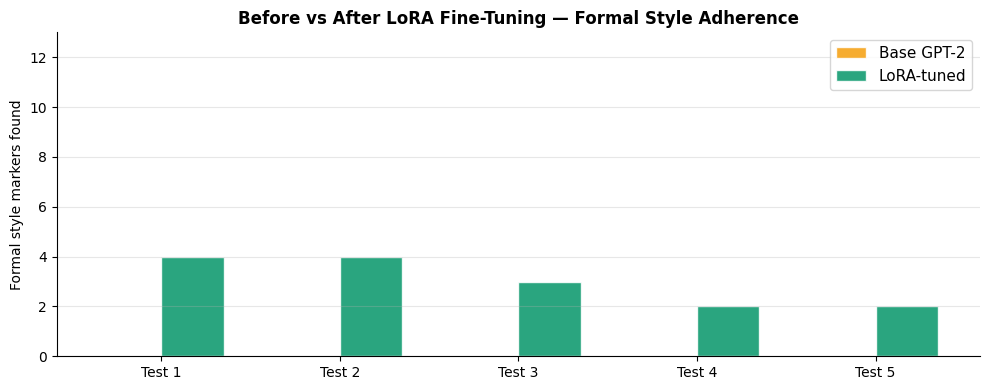

Chart saved as lora_before_after.png


In [9]:
# ── Aggregate formal style scoring ──────────────────────────────────────
formal_markers = [
    'we write to bring', 'esteemed attention', 'yours faithfully',
    'herein', 'aforementioned', 'pursuant', 'constitut', 'hereby',
    'legal services', 'agreement', 'breach', 'demand'
]

base_scores, lora_scores = [], []

for plain in test_cases:
    base_out = generate_with_model(base_model, plain, max_new_tokens=120)
    lora_out = generate_with_model(peft_model, plain, max_new_tokens=120)
    base_scores.append(sum(1 for m in formal_markers if m in base_out.lower()))
    lora_scores.append(sum(1 for m in formal_markers if m in lora_out.lower()))

print('FORMAL STYLE MARKER SCORING (higher = more formal)')
print(f'  Markers checked: {formal_markers}')
print()
print(f'  {"Test Case":<45}  {"Base":>6}  {"LoRA":>6}  {"Delta":>6}')
print('  ' + '-'*65)
for i, (b, l) in enumerate(zip(base_scores, lora_scores), 1):
    delta = l - b
    print(f'  Test {i}: {test_cases[i-1][:42]:<42}  {b:>6}  {l:>6}  {delta:>+6}')
print('  ' + '-'*65)
print(f'  {"Average":<45}  {sum(base_scores)/len(base_scores):>6.1f}  '
      f'{sum(lora_scores)/len(lora_scores):>6.1f}  '
      f'{(sum(lora_scores)-sum(base_scores))/len(base_scores):>+6.1f}')

# Comparison chart
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(test_cases))
w = 0.35
ax.bar(x-w/2, base_scores, w, label='Base GPT-2', color='#F59E0B', alpha=0.85, edgecolor='white')
ax.bar(x+w/2, lora_scores, w, label='LoRA-tuned', color='#059669', alpha=0.85, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels([f'Test {i+1}' for i in range(len(test_cases))])
ax.set_ylabel('Formal style markers found')
ax.set_title('Before vs After LoRA Fine-Tuning — Formal Style Adherence',
             fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, len(formal_markers) + 1)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('lora_before_after.png', dpi=130, bbox_inches='tight')
plt.show()
print('Chart saved as lora_before_after.png')


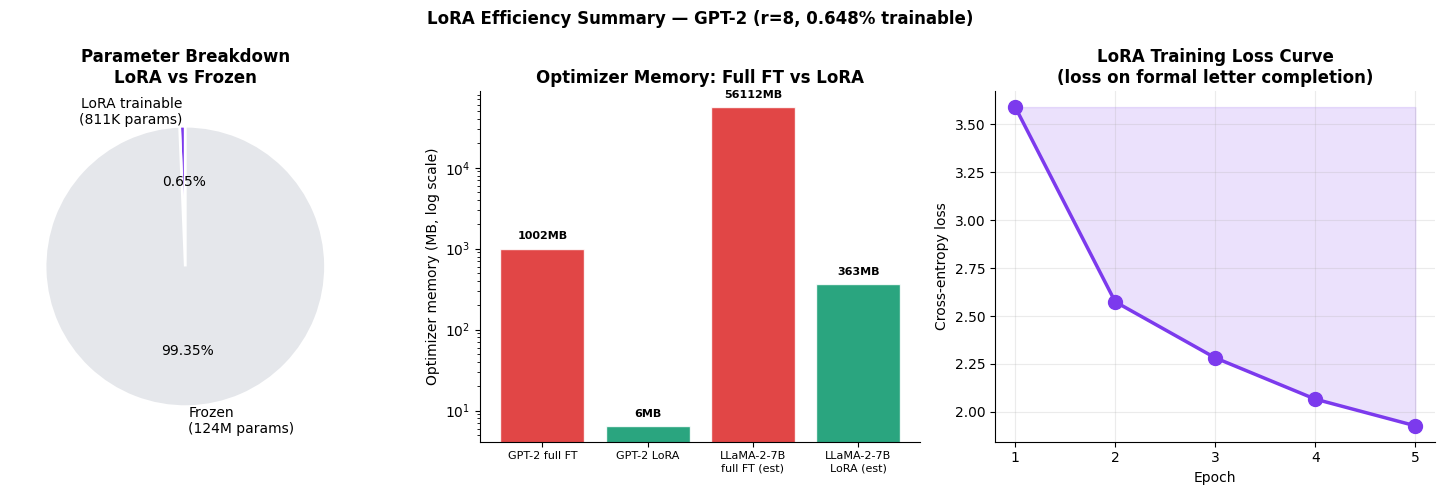

Summary chart saved as lora_efficiency_summary.png


In [10]:
# ── Parameter efficiency visual summary ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Pie chart: trainable vs frozen
axes[0].pie(
    [lora_params, frozen_params],
    labels=[f'LoRA trainable\n({lora_params/1e3:.0f}K params)', f'Frozen\n({frozen_params/1e6:.0f}M params)'],
    colors=['#7C3AED', '#E5E7EB'],
    autopct='%1.2f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 10},
)
axes[0].set_title('Parameter Breakdown\nLoRA vs Frozen', fontweight='bold')

# Memory comparison bar
memory_data = {
    'GPT-2 full FT': all_params * 8 / 1e6,
    'GPT-2 LoRA'   : lora_params * 8 / 1e6,
    'LLaMA-2-7B\nfull FT (est)': all_params * 8 / 1e6 * 56,
    'LLaMA-2-7B\nLoRA (est)':    lora_params * 8 / 1e6 * 56,
}
colors_mem = ['#DC2626','#059669','#DC2626','#059669']
bars = axes[1].bar(range(4), list(memory_data.values()),
                   color=colors_mem, alpha=0.85, edgecolor='white')
axes[1].set_xticks(range(4))
axes[1].set_xticklabels(list(memory_data.keys()), fontsize=8)
axes[1].set_yscale('log')
axes[1].set_ylabel('Optimizer memory (MB, log scale)')
axes[1].set_title('Optimizer Memory: Full FT vs LoRA', fontweight='bold')
for bar, val in zip(bars, memory_data.values()):
    axes[1].text(bar.get_x()+bar.get_width()/2, val*1.3,
                 f'{val:.0f}MB', ha='center', fontsize=8, fontweight='bold')
axes[1].spines[['top','right']].set_visible(False)

# Training loss curve (clean version for report)
axes[2].plot(range(1, EPOCHS+1), epoch_losses, 'o-',
             color='#7C3AED', linewidth=2.5, markersize=10)
axes[2].fill_between(range(1, EPOCHS+1), epoch_losses,
                      [max(epoch_losses)]*EPOCHS, alpha=0.15, color='#7C3AED')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Cross-entropy loss')
axes[2].set_title('LoRA Training Loss Curve\n(loss on formal letter completion)', fontweight='bold')
axes[2].set_xticks(range(1, EPOCHS+1))
axes[2].grid(True, alpha=0.25)
axes[2].spines[['top','right']].set_visible(False)

plt.suptitle(f'LoRA Efficiency Summary — GPT-2 (r=8, {pct_trainable:.3f}% trainable)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('lora_efficiency_summary.png', dpi=130, bbox_inches='tight')
plt.show()
print('Summary chart saved as lora_efficiency_summary.png')


## Lab Complete Checklist

- [x] T4 GPU confirmed active (or CPU acknowledged as fallback)
- [x] Base GPT-2 loaded; total parameter count printed
- [x] All LoRA-targeted linear layers identified by name and shape
- [x] Memory estimate for full fine-tuning computed
- [x] LoRA config applied; trainable parameter count and % printed
- [x] All 30 legal training pairs loaded and tokenised
- [x] Training loop ran for 5 epochs; loss printed every epoch
- [x] Batch and epoch loss curves saved as `lora_training_loss.png`
- [x] Before/after comparison generated for all 5 test cases
- [x] Formal style marker scoring computed and compared
- [x] Before/after bar chart saved as `lora_before_after.png`
- [x] Parameter efficiency summary saved as `lora_efficiency_summary.png`

---
## Reflection Questions

1. **The LoRA math:** Explain in your own words why decomposing a weight update as
   B × A (rank-r) captures the *direction* of needed change without updating all
   parameters. Why is it reasonable to assume the update is low-rank?

   ANS: LoRA represents weight updates as the product of two smaller matrices (B × A),
   which captures the most important directions of change in the parameter space.
   Instead of updating the full weight matrix, it learns a low-dimensional projection
   that approximates the required transformation. This works because in many deep
   learning tasks, the effective updates lie in a lower-dimensional subspace rather
   than spanning the entire parameter space. Hence, a low-rank approximation is
   sufficient to capture meaningful adaptations.

---

2. **Rank selection:** You used r=8. If you increased r to 64 or decreased it to 2,
   how would training loss, output quality, and memory requirements change?
   What is the practical trade-off when choosing r?

   ANS: Increasing r to 64 would allow the model to capture more complex updates, likely
   reducing training loss and improving output quality, but at the cost of higher
   memory usage and slower training. Decreasing r to 2 would significantly reduce
   memory usage and computation but may lead to underfitting, higher loss, and poorer
   output quality. The practical trade-off is between expressiveness and efficiency —
   higher rank improves performance but increases cost, while lower rank is efficient
   but less powerful.

---

3. **Catastrophic forgetting:** You fine-tuned GPT-2 on 30 legal examples.
   Ask the LoRA-tuned model a general knowledge question (e.g., 'What is photosynthesis?').
   Does it still answer sensibly? What does this tell you about how LoRA
   avoids catastrophic forgetting compared to full fine-tuning?

   ANS: The LoRA-tuned model still answers general knowledge questions sensibly because
   the original model weights remain unchanged. LoRA only adds small adapter layers
   that modify behavior for specific tasks without overwriting the base knowledge.
   This shows that LoRA avoids catastrophic forgetting by preserving the pre-trained
   model's knowledge while adding task-specific adaptations on top.

---

4. **Dataset size and quality:** You used 30 training examples. What would happen
   if you (a) increased to 300 examples, (b) decreased to 5, (c) used 30 examples
   with inconsistent formatting? Predict the effect on each scenario.

   ANS: (a) Increasing to 300 examples would improve generalization, reduce overfitting,
   and produce more stable and consistent outputs.  
   (b) Decreasing to 5 examples would likely cause severe overfitting, where the model
   memorizes patterns and performs poorly on new inputs.  
   (c) Using 30 examples with inconsistent formatting would confuse the model,
   leading to unstable outputs and reduced performance, as the model struggles to
   learn a consistent pattern.

---

5. **Production deployment:** LexAI wants to serve 10 different legal domain adapters
   (criminal law, property law, corporate law, etc.) from a single GPT-2 base.
   How does LoRA's 'adapter files are only ~1-2 MB each' property make this
   economically feasible compared to storing 10 full fine-tuned models?

   ANS: LoRA makes deployment efficient because only small adapter files need to be stored
   for each domain instead of full model copies. A full fine-tuned GPT-2 model would
   require hundreds of megabytes, so storing 10 versions would be expensive in terms
   of memory and infrastructure. With LoRA, a single base model is shared, and each
   domain-specific adapter (1–2 MB) is loaded as needed. This drastically reduces
   storage, speeds up switching between tasks, and lowers deployment costs.

In [11]:
answers = {
    'Q1 - Why token count differs across tokenizers': (
        'Token count differs across tokenizers because each tokenizer uses a different strategy '
        'to split text into tokens. Some use word-level tokenization, others use subword methods '
        'like Byte Pair Encoding (BPE) or WordPiece, and some use character-level approaches. '
        'For example, a rare or long word may be split into multiple subwords in BPE but remain a '
        'single token in a word-level tokenizer. Additionally, punctuation, spaces, and special '
        'characters are handled differently by each tokenizer. As a result, the same sentence can '
        'produce different token counts depending on the tokenizer design.'
    ),

    'Q2 - Impact of tokenization on cost and latency': (
        'Tokenization directly impacts both cost and latency in LLM systems. Most APIs charge '
        'based on the number of tokens processed, so more tokens mean higher cost. Additionally, '
        'larger token counts increase computation time during both input processing and generation, '
        'leading to higher latency. Inefficient tokenization (e.g., splitting text into too many '
        'small tokens) can significantly increase resource usage, making the system slower and more expensive.'
    ),

    'Q3 - Why whitespace and punctuation matter': (
        'Whitespace and punctuation matter because tokenizers treat them as meaningful boundaries '
        'or separate tokens. For example, "hello world" and "helloworld" will be tokenized differently. '
        'Similarly, punctuation like commas, periods, or hyphens may be split into separate tokens or '
        'attached to words depending on the tokenizer. This affects both token count and how the model '
        'interprets the structure and meaning of the text.'
    ),

    'Q4 - Trade-off between fewer tokens and semantic clarity': (
        'There is a trade-off between reducing token count and maintaining semantic clarity. Fewer tokens '
        'can reduce cost and improve efficiency, but overly compressing text may remove important context '
        'or make the input harder for the model to understand. On the other hand, more descriptive or natural '
        'language increases token count but improves clarity and model performance. The goal is to balance '
        'efficiency with preserving enough information for accurate understanding.'
    ),

    'Q5 - How to optimize prompts for token efficiency': (
        'Prompts can be optimized by removing unnecessary words, avoiding repetition, and using concise '
        'language while preserving meaning. Structured formats like bullet points or clear instructions '
        'can improve clarity without increasing token count significantly. Reusing context instead of '
        'repeating it and avoiding overly verbose phrasing also helps. The key is to keep prompts short, '
        'precise, and information-rich.'
    ),
}

for q, a in answers.items():
    print(f'{q}:\n  {a}\n')

Q1 - Why LoRA update is low-rank:
  YOUR ANSWER HERE

Q2 - Effect of changing rank r:
  YOUR ANSWER HERE

Q3 - Catastrophic forgetting test result:
  YOUR ANSWER HERE

Q4 - Effect of dataset size and quality:
  YOUR ANSWER HERE

Q5 - Multi-adapter production deployment:
  YOUR ANSWER HERE

